# 00. Raw data, the dilution convention, and what the controls allow

This notebook loads the laboratory readings exactly as they were reported and
establishes what can and cannot be calculated from them. Everything in the
other three notebooks depends on the decisions made here.

Two facts govern the whole analysis:

1. The laboratory reported a reading and a dilution factor for each sample.
   Its working notes were not available, so the convention
   `concentration = reading x dilution factor` is inferred from the report
   layout. Absolute concentrations therefore carry an unresolved uncertainty.
2. The measured stock and control solutions did not match their nominal
   values. Removal is therefore calculated against the **measured** control
   analysed at the same dilution, not against the nominal 400 mg/L.

In [1]:
import sys
sys.path.insert(0, "src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from adsorption import concentration, removal_pct, uptake

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

raw = pd.read_csv("data/aas_readings.csv")
print(f"{len(raw)} readings transcribed from Appendix A of the thesis")
print()
print(raw.groupby(["series", "metal"]).size().to_string())

60 readings transcribed from Appendix A of the thesis

series         metal
concentration  Mn       5
               Zn       5
control        Mn       1
               Zn       1
dose           Mn       5
               Zn       5
pH             Mn       6
               Zn       6
stock          Mn       1
               Zn       1
temperature    Mn       6
               Zn       6
time           Mn       6
               Zn       6


## Controls and stock solutions

If the preparation and the analysis were both sound, the measured stock should
sit near 1000 mg/L, the measured control near 400 mg/L, and the ratio between
them near 2.5. None of that holds.

In [2]:
controls = raw[raw["series"].isin(["stock", "control"])].copy()
controls["measured_mg_L"] = concentration(controls["reading_mg_L"],
                                          controls["dilution_factor"])
controls["measured_over_nominal"] = (controls["measured_mg_L"]
                                     / controls["nominal_C0_mg_L"]).round(2)

print(controls[["metal", "label", "dilution_factor", "reading_mg_L",
                "measured_mg_L", "nominal_C0_mg_L",
                "measured_over_nominal"]].to_string(index=False))
print()

for metal in ["Mn", "Zn"]:
    sub = controls[controls["metal"] == metal].set_index("series")
    ratio = sub.loc["stock", "measured_mg_L"] / sub.loc["control", "measured_mg_L"]
    print(f"{metal}: measured stock / measured control = {ratio:.1f}  "
          f"(expected 2.5 from the dilution recipe)")

metal       label  dilution_factor  reading_mg_L  measured_mg_L  nominal_C0_mg_L  measured_over_nominal
   Mn control_400             10.0        13.100         131.00              400                   0.33
   Zn control_400             50.0         2.861         143.05              400                   0.36
   Mn   stock_SSS             50.0        10.600         530.00             1000                   0.53
   Zn   stock_SSS             50.0         3.279         163.95             1000                   0.16

Mn: measured stock / measured control = 4.0  (expected 2.5 from the dilution recipe)
Zn: measured stock / measured control = 1.1  (expected 2.5 from the dilution recipe)


The Mn ratio is 4.0 and the Zn ratio is 1.1, against an expected 2.5. Possible
causes include readings outside the instrument's linear working range, errors
in solution preparation, losses during the weeks the filtrates were stored
before analysis, and the unrecorded hydration state of the manganese salt.

The practical consequence is that **absolute uptake values are provisional**,
while **removal percentages are not**, provided the sample and the control were
measured at the same dilution. In that case the dilution factor cancels:

$$\text{Removal} = \frac{C_0 - C_e}{C_0} = \frac{R_0 \cdot DF - R_e \cdot DF}{R_0 \cdot DF}$$

## Can the manganese salt explain the gap?

One candidate explanation is stoichiometric. The hydration state of the
manganese(II) sulfate was not recorded, and 1.3735 g of the anhydrous salt and
1.3735 g of a hydrate contain different amounts of manganese. If the reagent
was a hydrate, the nominal stock concentration was overstated from the start.

This is testable.

In [3]:
MOLAR = {
    "MnSO4 (anhydrous)": 151.00,
    "MnSO4.H2O (monohydrate)": 169.02,
    "MnSO4.4H2O (tetrahydrate)": 223.06,
}
M_MN = 54.938
MASS_G, VOLUME_L = 1.3735, 0.500

print("1.3735 g made up to 500 mL:\n")
for name, mm in MOLAR.items():
    mg_per_L = MASS_G * (M_MN / mm) / VOLUME_L * 1000
    print(f"  as {name:28s} -> {mg_per_L:6.0f} mg/L Mn")

measured_stock = 530.0
print(f"\nMeasured Mn stock: {measured_stock:.0f} mg/L")
for name, mm in MOLAR.items():
    mg_per_L = MASS_G * (M_MN / mm) / VOLUME_L * 1000
    print(f"  recovery against {name:28s} = "
          f"{measured_stock / mg_per_L * 100:5.1f}%")

# The zinc salt hydration WAS recorded, as the heptahydrate
zn_mg_per_L = 2.1975 * (65.38 / 287.56) / VOLUME_L * 1000
print(f"\nZn stock as ZnSO4.7H2O: {zn_mg_per_L:.0f} mg/L nominal, "
      f"164 mg/L measured ({164 / zn_mg_per_L * 100:.0f}% recovery)")

1.3735 g made up to 500 mL:

  as MnSO4 (anhydrous)            ->    999 mg/L Mn
  as MnSO4.H2O (monohydrate)      ->    893 mg/L Mn
  as MnSO4.4H2O (tetrahydrate)    ->    677 mg/L Mn

Measured Mn stock: 530 mg/L
  recovery against MnSO4 (anhydrous)            =  53.0%
  recovery against MnSO4.H2O (monohydrate)      =  59.4%
  recovery against MnSO4.4H2O (tetrahydrate)    =  78.3%

Zn stock as ZnSO4.7H2O: 999 mg/L nominal, 164 mg/L measured (16% recovery)


Even the tetrahydrate would give 677 mg/L, so the measured 530 mg/L is not
explained by hydration alone, and the zinc salt had a recorded hydration state
yet recovered only 16%. The hydration ambiguity shifts the nominal figure but
does not account for the discrepancy, which is why the analysis works from the
measured control throughout rather than trying to correct the nominal value.

## Deriving removal and uptake for every sample

For the concentration series the initial concentration was not measured at each
level, so it is scaled from the measured 400 mg/L control in proportion to the
dilution recipe. That is an assumption, and it is carried forward explicitly.

In [4]:
CONTROL_CONC = {
    m: float(concentration(
        raw.loc[(raw.series == "control") & (raw.metal == m), "reading_mg_L"].iloc[0],
        raw.loc[(raw.series == "control") & (raw.metal == m), "dilution_factor"].iloc[0]))
    for m in ["Mn", "Zn"]
}
print("measured control concentrations (mg/L):", CONTROL_CONC)

work = raw[~raw["series"].isin(["stock", "control"])].copy()
work["Ce_mg_L"] = concentration(work["reading_mg_L"], work["dilution_factor"])
work["C0_mg_L"] = [CONTROL_CONC[m] * n / 400.0
                   for m, n in zip(work["metal"], work["nominal_C0_mg_L"])]
work["removal_pct"] = removal_pct(work["C0_mg_L"], work["Ce_mg_L"])
work["q_mg_g"] = uptake(work["C0_mg_L"], work["Ce_mg_L"],
                        work["volume_L"], work["mass_g"])

cols = ["metal", "label", "dilution_factor", "reading_mg_L", "Ce_mg_L",
        "removal_pct", "q_mg_g"]
for series in ["dose", "time", "concentration", "pH", "temperature"]:
    print()
    print(f"--- {series} series ---")
    print(work[work["series"] == series][cols].round(3).to_string(index=False))

measured control concentrations (mg/L): {'Mn': 131.0, 'Zn': 143.05}

--- dose series ---
metal     label  dilution_factor  reading_mg_L  Ce_mg_L  removal_pct  q_mg_g
   Mn dose_0.2g             10.0        12.580   125.80        3.969   1.300
   Mn dose_0.4g             10.0        11.610   116.10       11.374   1.863
   Mn dose_0.6g             10.0        11.210   112.10       14.427   1.575
   Mn dose_0.8g             10.0         9.850    98.50       24.809   2.031
   Mn dose_1.0g             10.0         8.950    89.50       31.679   2.075
   Zn dose_0.2g             50.0         1.796    89.80       37.225  13.313
   Zn dose_0.4g             50.0         2.647   132.35        7.480   1.338
   Zn dose_0.6g             50.0         2.630   131.50        8.074   0.963
   Zn dose_0.8g             50.0         2.491   124.55       12.933   1.156
   Zn dose_1.0g             50.0         2.339   116.95       18.245   1.305

--- time series ---
metal           label  dilution_factor  rea

Note the `NaN` row: the Mn 100 mg/L sample has no reported dilution factor, so
no concentration can be derived from it. It is excluded everywhere rather than
assigned a guessed factor.

## Cross-check against the thesis tables

Every derived value is checked against the figure printed in the thesis. If the
transcription or the arithmetic were wrong, this cell would fail.

In [5]:
def removal_of(metal, label):
    row = work[(work.metal == metal) & (work.label == label)].iloc[0]
    return row["removal_pct"], row["q_mg_g"]

checks = [
    ("Mn", "dose_0.2g", 4.0, 1.30),      # Table 9
    ("Mn", "dose_1.0g", 31.7, 2.08),
    ("Zn", "dose_0.2g", 37.2, 13.31),
    ("Zn", "dose_1.0g", 18.2, 1.31),
    ("Mn", "time_120_dirt", 13.5, 1.47),  # Table 10
    ("Zn", "time_90", 26.8, 3.20),
    ("Mn", "pH_9", 92.0, None),           # Table 11
    ("Zn", "pH_11", 98.2, None),
    ("Mn", "conc_500", 15.3, 2.09),       # Table 13
    ("Zn", "conc_300", 31.7, 2.83),
    ("Mn", "temp_27", 20.7, None),        # Table 12
    ("Zn", "temp_37", 54.5, None),
]

for metal, label, exp_removal, exp_q in checks:
    got_r, got_q = removal_of(metal, label)
    assert abs(got_r - exp_removal) < 0.1, (metal, label, got_r, exp_removal)
    if exp_q is not None:
        assert abs(got_q - exp_q) < 0.02, (metal, label, got_q, exp_q)
    print(f"OK  {metal} {label:16s} removal {got_r:6.1f}%  (thesis {exp_removal}%)")

print()
print("All 12 cross-checks against the thesis tables passed.")

OK  Mn dose_0.2g        removal    4.0%  (thesis 4.0%)
OK  Mn dose_1.0g        removal   31.7%  (thesis 31.7%)
OK  Zn dose_0.2g        removal   37.2%  (thesis 37.2%)
OK  Zn dose_1.0g        removal   18.2%  (thesis 18.2%)
OK  Mn time_120_dirt    removal   13.5%  (thesis 13.5%)
OK  Zn time_90          removal   26.8%  (thesis 26.8%)
OK  Mn pH_9             removal   92.0%  (thesis 92.0%)
OK  Zn pH_11            removal   98.2%  (thesis 98.2%)
OK  Mn conc_500         removal   15.3%  (thesis 15.3%)
OK  Zn conc_300         removal   31.7%  (thesis 31.7%)
OK  Mn temp_27          removal   20.7%  (thesis 20.7%)
OK  Zn temp_37          removal   54.5%  (thesis 54.5%)

All 12 cross-checks against the thesis tables passed.


## How large a difference is real?

No replicate flasks were run. The only estimate of variability comes from the
reference condition (nominal 400 mg/L, 12 g/L, 120 min), which occurs by
accident in three separate experimental series. This sets the floor below which
differences cannot be interpreted.

Mn: readings [11.21 11.33 11.46]  mean 11.33  RSD 1.1%
    removals [14.4 13.5 12.5]  spread 1.9 percentage points

Zn: readings [2.63  2.385 2.19 ]  mean 2.40  RSD 9.2%
    removals [ 8.1 16.6 23.5]  spread 15.4 percentage points



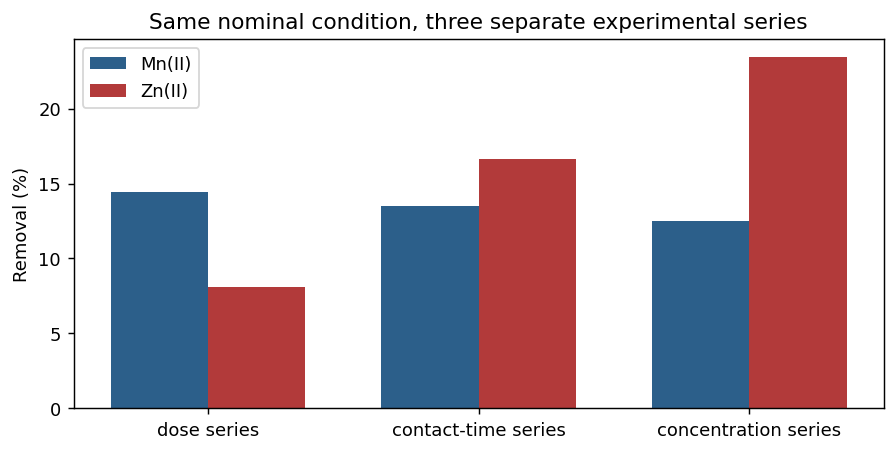

In [6]:
REF = {"Mn": ["dose_0.6g", "time_120_dirt", "conc_400"],
       "Zn": ["dose_0.6g", "time_120_sample", "conc_400"]}
SERIES_NAME = ["dose series", "contact-time series", "concentration series"]

summary = {}
for metal, labels in REF.items():
    sub = work[(work.metal == metal) & (work.label.isin(labels))]
    sub = sub.set_index("label").loc[labels]
    readings = sub["reading_mg_L"].to_numpy()
    removals = sub["removal_pct"].to_numpy()
    rsd = readings.std(ddof=1) / readings.mean() * 100
    summary[metal] = (removals, rsd)
    print(f"{metal}: readings {readings}  mean {readings.mean():.2f}  "
          f"RSD {rsd:.1f}%")
    print(f"    removals {np.round(removals, 1)}  "
          f"spread {removals.max() - removals.min():.1f} percentage points")
    print()

fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(3)
ax.bar(x - 0.18, summary["Mn"][0], 0.36, label="Mn(II)", color="#2c5f8a")
ax.bar(x + 0.18, summary["Zn"][0], 0.36, label="Zn(II)", color="#b23a3a")
ax.set_xticks(x)
ax.set_xticklabels(SERIES_NAME)
ax.set_ylabel("Removal (%)")
ax.set_title("Same nominal condition, three separate experimental series")
ax.legend()
fig.tight_layout()

## What this notebook establishes

- Removal percentages are robust to the dilution convention when sample and
  control share a dilution. Absolute `q` values are not, and are labelled
  provisional throughout.
- For Mn(II) the three reference-condition readings agree to 1.1% RSD, so
  removal differences of roughly 1 to 2 percentage points are at the edge of
  what the data can resolve.
- For Zn(II) the RSD is 9.2% and the three removals span 8.1 to 23.5%. **Any
  Zn(II) difference smaller than about 8 percentage points is not interpretable
  as a real effect.** This single number constrains the conclusions in the next
  three notebooks more than any model fit does.
- The Mn 100 mg/L point and the undiluted Zn 100 and 200 mg/L points sit on a
  different analytical basis from the rest and are excluded rather than
  silently merged in.